In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [21]:
import pandas as pd

df = pd.read_csv('./data/Mall_Customers.csv', encoding='euc-kr')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
# CustomerID 제거, 성별 인코딩
df['Gender'] = (df['Gender'].str.strip() == 'Male').astype(int)
# df['Gender'] = (df['Gender'] == 'Male').astype(int)
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].values

X

array([[ 19,  15,  39,   1],
       [ 21,  15,  81,   1],
       [ 20,  16,   6,   0],
       [ 23,  16,  77,   0],
       [ 31,  17,  40,   0],
       [ 22,  17,  76,   0],
       [ 35,  18,   6,   0],
       [ 23,  18,  94,   0],
       [ 64,  19,   3,   1],
       [ 30,  19,  72,   0],
       [ 67,  19,  14,   1],
       [ 35,  19,  99,   0],
       [ 58,  20,  15,   0],
       [ 24,  20,  77,   0],
       [ 37,  20,  13,   1],
       [ 22,  20,  79,   1],
       [ 35,  21,  35,   0],
       [ 20,  21,  66,   1],
       [ 52,  23,  29,   1],
       [ 35,  23,  98,   0],
       [ 35,  24,  35,   1],
       [ 25,  24,  73,   1],
       [ 46,  25,   5,   0],
       [ 31,  25,  73,   1],
       [ 54,  28,  14,   0],
       [ 29,  28,  82,   1],
       [ 45,  28,  32,   0],
       [ 35,  28,  61,   1],
       [ 40,  29,  31,   0],
       [ 23,  29,  87,   0],
       [ 60,  30,   4,   1],
       [ 21,  30,  73,   0],
       [ 53,  33,   4,   1],
       [ 18,  33,  92,   1],
       [ 49,  

In [34]:
# StandardScaler로 x 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.42456879, -1.73899919, -0.43480148,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992, -0.88640526],
       [-1.20926872, -1.66266033,  1.00159627, -0.88640526],
       [-0.27630176, -1.62449091, -1.71591298, -0.88640526],
       [-1.13750203, -1.62449091,  1.70038436, -0.88640526],
       [ 1.80493225, -1.58632148, -1.83237767,  1.12815215],
       [-0.6351352 , -1.58632148,  0.84631002, -0.88640526],
       [ 2.02023231, -1.58632148, -1.4053405 ,  1.12815215],
       [-0.27630176, -1.58632148,  1.89449216, -0.88640526],
       [ 1.37433211, -1.54815205, -1.36651894, -0.88640526],
       [-1.06573534, -1.54815205,  1.04041783, -0.88640526],
       [-0.13276838, -1.54815205, -1.44416206,  1.12815215],
       [-1.20926872, -1.54815205,  1.11806095,  1.12815215],
       [-0.27630176, -1.

In [35]:
# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca_scaled = pca.fit_transform(X_scaled)

print("스케일링 후 설명분산비율:", pca.explained_variance_ratio_)
print("스케일링 후 누적설명분산:", sum(pca.explained_variance_ratio_))

X_pca_scaled

스케일링 후 설명분산비율: [0.33690046 0.26230645]
스케일링 후 누적설명분산: 0.5992069019819847


array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

C:\Users\Admin\AppData\Local\Temp\ipykernel_18200\1285899958.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


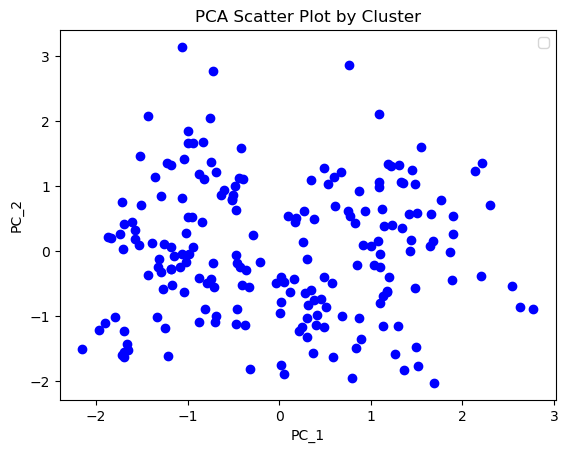

In [40]:
colors = ['blue', 'green', 'red', 'orange']

plt.scatter(X_pca_scaled[:,0], X_pca_scaled[:,1], color='blue')

plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.title('PCA Scatter Plot by Cluster')
plt.legend()
plt.show()

# KMEANS 클러스터링 

c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a m

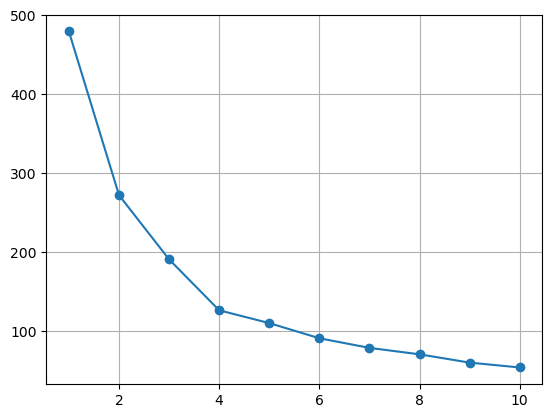

In [37]:
# import
k_values = range(1, 11)
sse_values = []

# scree_df = iris_df.drop(columns=['target', 'cluster', 'silhouette'])

for i in k_values :
    kmi = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=0)
    kmi.fit(X_pca_scaled)
    
    sse_values.append(kmi.inertia_)
    
sse_values

plt.plot(k_values, sse_values, marker='o')
plt.grid()
plt.show()

array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

In [ ]:
km4 = KMeans(n_clusters=4, init='k-means++', max_iter=300, random_state=0)
km4.fit(X_pca_scaled)


df['cluster'] = km4.labels_

df

c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,2
3,4,0,23,16,77,3
4,5,0,31,17,40,2
...,...,...,...,...,...,...
195,196,0,35,120,79,1
196,197,0,45,126,28,0
197,198,1,32,126,74,1
198,199,1,32,137,18,1


# KMeans 클러스터링 결과 시각화

In [71]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_score(X_pca_scaled, df['cluster'])  # 전체 Sample에 대한 평균 실루엣 계수
df['silhouette'] = silhouette_samples(X_pca_scaled, df['cluster'])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster,silhouette
0,1,1,19,15,39,3,0.192957
1,2,1,21,15,81,3,0.580635
2,3,0,20,16,6,2,0.387865
3,4,0,23,16,77,3,0.435841
4,5,0,31,17,40,2,0.202205


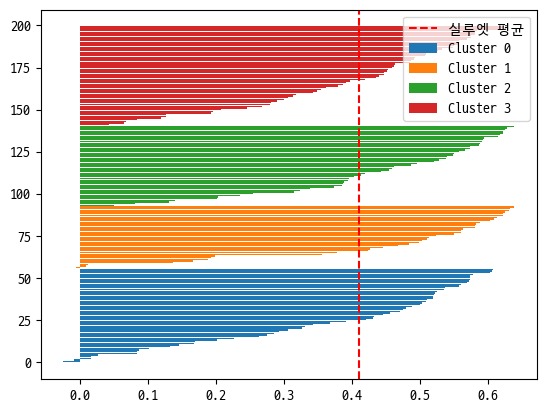

In [45]:
# KMEANS 클러스터링 
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'D2Coding'   # Linux(나눔폰트 설치 시)
plt.rcParams['axes.unicode_minus'] = False      # - 기호 깨짐 방지

y_lower = 0

for i in range(4) :
    cluster = df[df['cluster'] == i]['silhouette'].sort_values()
    
    y_upper = y_lower + len(cluster)
    
    plt.barh(range(y_lower, y_upper), cluster, label=f"Cluster {i}")
    
    y_lower = y_upper


# 평균선 그리기
avg_score = silhouette_score(X_pca_scaled, df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label='실루엣 평균')

plt.legend()
plt.show()


In [61]:
sum_sf = df.drop(columns=['CustomerID']).groupby('cluster').mean()
sum_sf['count'] = df.drop(columns=['CustomerID']).groupby('cluster')['Gender'].count()

sum_sf.sort_values('Gender', axis=0, ascending=False)

,Gender,Age,Annual Income (k$),Spending Score (1-100),silhouette,count
cluster,,,,,,
1,0.837838,30.270270,81.189189,71.486486,0.448351,37
0,0.785714,49.357143,70.500000,28.250000,0.371044,56
3,0.169492,27.135593,50.118644,68.067797,0.394665,59
2,0.062500,47.604167,45.895833,37.437500,0.446814,48


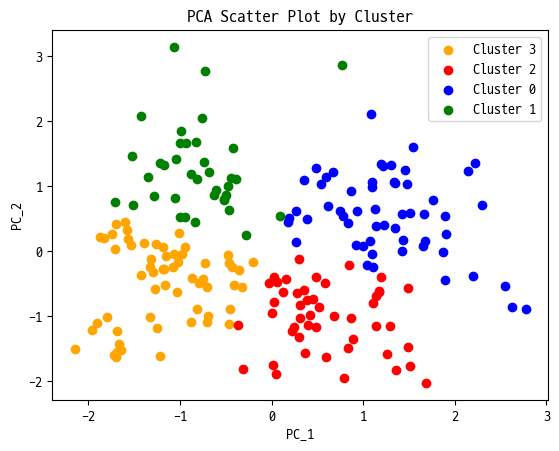

In [73]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'D2Coding'   # Linux(나눔폰트 설치 시)
plt.rcParams['axes.unicode_minus'] = False      # - 기호 깨짐 방지

pca_df = pd.DataFrame(X_pca_scaled, columns=['PCA_1', 'PCA_2'])
pca_df['cluster'] =  df['cluster']

pca_df.head()

colors = ['blue', 'green', 'red', 'orange']
for cluster in pca_df['cluster'].unique() :
    sel_df = pca_df[pca_df['cluster']==cluster]
    plt.scatter(sel_df['PCA_1'], sel_df['PCA_2'], color=colors[cluster], label=f"Cluster {cluster}")

plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.title('PCA Scatter Plot by Cluster')
plt.legend()
plt.show()

In [77]:
features = ['Gender', 'Age', 
            'AnualIncome', 'Score']

loadings_scaled = pd.DataFrame(
    pca.components_.T,
    columns=['PC_1', 'PC_2'],
    index=features
)

print("\n=== 스케일링 후 설명분산비율 ===")
print(pca.explained_variance_ratio_)

print("\n=== 스케일링 후 로딩값 ===")
print(loadings_scaled)


=== 스케일링 후 설명분산비율 ===
[0.33690046 0.26230645]

=== 스케일링 후 로딩값 ===
                 PC_1      PC_2
Gender       0.687900 -0.103690
Age         -0.006082  0.765252
AnualIncome -0.686920  0.103211
Score        0.234302  0.626886


# 3차원 축소

In [82]:
# PCA 객체 생성 (주성분 3개로 축소)
pca3 = PCA(n_components=3)

# 데이터 변환
X_pca_scaled3 = pca3.fit_transform(X_scaled)

print("스케일링 후 설명분산비율:", pca3.explained_variance_ratio_)
print("스케일링 후 누적설명분산:", sum(pca3.explained_variance_ratio_))

스케일링 후 설명분산비율: [0.33690046 0.26230645 0.23260639]
스케일링 후 누적설명분산: 0.8318132878845951


In [81]:
features = ['Gender', 'Age', 
            'AnualIncome', 'Score']

loadings_scaled = pd.DataFrame(
    pca3.components_.T,
    columns=['PC_1', 'PC_2', 'PC_3'],
    index=features
)

print("\n=== 스케일링 후 설명분산비율 ===")
print(pca.explained_variance_ratio_)

print("\n=== 스케일링 후 로딩값 ===")
print(loadings_scaled)


=== 스케일링 후 설명분산비율 ===
[0.33690046 0.26230645]

=== 스케일링 후 로딩값 ===
                 PC_1      PC_2      PC_3
Gender       0.687900 -0.103690 -0.122384
Age         -0.006082  0.765252 -0.643667
AnualIncome -0.686920  0.103211  0.136573
Score        0.234302  0.626886  0.743009
